# Larger Balanced Synthetic IPv6 Dataset and Model Evaluation

This notebook comes before the transfer-diagnostic notebook in the final order. The earlier synthetic dataset had very few useful points and the models performed poorly on it, so I reused the synthetic generation logic to create a larger and more balanced IPv6-oriented dataset.

The new dataset is grounded in UNSW-NB15 rows, keeps the UNSW-compatible feature schema, adds IPv6 metadata, and then tests saved final-model checkpoints on the generated synthetic test split. This connects directly to the thesis aim: improving the accuracy and reliability of the synthetic dataset evaluation.


In [2]:
import os
import json
import math
import random
import zipfile
import shutil
import ipaddress
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

KAGGLE_INPUT_ROOT = Path("/kaggle/input") if Path("/kaggle/input").exists() else None

def find_all(pattern):
    hits = []
    if KAGGLE_INPUT_ROOT is not None:
        hits.extend(glob for glob in KAGGLE_INPUT_ROOT.rglob(pattern))
    hits.extend(Path("/mnt/data").rglob(pattern))
    uniq = []
    seen = set()
    for p in hits:
        p = Path(p)
        if str(p) not in seen:
            uniq.append(p)
            seen.add(str(p))
    return uniq

def find_first(patterns):
    for pat in patterns:
        hits = find_all(pat)
        if hits:
            return hits[0]
    return None

OUTPUT_ROOT = Path("balanced_ipv6_generation_and_eval")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

UNSW_TEST_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"
UNSW_TRAIN_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"

FINAL_ARTIFACTS_DIR = "/kaggle/input/datasets/models-and-results-unsw/final_model_artifacts"

print("UNSW train csv:", UNSW_TRAIN_CSV)
print("UNSW test csv :", UNSW_TEST_CSV)
print("Artifacts dir :", FINAL_ARTIFACTS_DIR)
print("Output root   :", OUTPUT_ROOT.resolve())


Device: cuda
UNSW train csv: /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv
UNSW test csv : /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv
Artifacts dir : /kaggle/input/datasets/models-and-results-unsw/final_model_artifacts
Output root   : /kaggle/working/balanced_ipv6_generation_and_eval


In [3]:
IMAGE_SIZE = 32
BINARY_BALANCE_MODE = "equalize_to_attack"   # "equalize_to_attack" or "custom_total"
CUSTOM_TOTAL = None                          # only used if BINARY_BALANCE_MODE="custom_total"
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20
SAVE_PNG_IMAGES = True
MAX_PNG_EXPORT = 3000   # keep practical; set None to export all thumbnails

NUMERIC_NOISE_STD = 0.06
ATTACK_NOISE_STD = 0.10

MODEL_IMAGE_SIZE = 128
BATCH_SIZE_EVAL = 128
NUM_WORKERS = 2
RUN_TASKS = ["binary", "multiclass"]  # evaluate both if checkpoints exist

BUNDLE_NAME = f"synthetic_ipv6_grounded_v4_balanced_{IMAGE_SIZE}x{IMAGE_SIZE}"
BUNDLE_ROOT = OUTPUT_ROOT / BUNDLE_NAME


## Load UNSW-NB15 Source Data

The UNSW-NB15 source data is loaded as the grounding pool for generation. The test set provides the flow records used for sampling and perturbation, while the training set is used later when reconstructing the saved model encoders.


In [4]:
assert UNSW_TEST_CSV is not None, "UNSW_NB15_testing-set.csv was not found."
unsw_test = pd.read_csv(UNSW_TEST_CSV)
unsw_test["attack_cat"] = unsw_test["attack_cat"].fillna("Normal").astype(str)

if UNSW_TRAIN_CSV is not None:
    unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
    unsw_train["attack_cat"] = unsw_train["attack_cat"].fillna("Normal").astype(str)
else:
    unsw_train = None

print("UNSW test shape:", unsw_test.shape)
print("UNSW binary counts:")
display(unsw_test["label"].value_counts(dropna=False).rename_axis("label").reset_index(name="count"))
print("UNSW attack categories:")
display(unsw_test["attack_cat"].value_counts(dropna=False).rename_axis("attack_cat").reset_index(name="count"))


UNSW test shape: (175341, 45)
UNSW binary counts:


,label,count
0,1,119341
1,0,56000


UNSW attack categories:


,attack_cat,count
0,Normal,56000
1,Generic,40000
2,Exploits,33393
3,Fuzzers,18184
4,DoS,12264
5,Reconnaissance,10491
6,Analysis,2000
7,Backdoor,1746
8,Shellcode,1133
9,Worms,130


## Generator Helpers

The helper functions create IPv6-style addresses and metadata, perturb numeric flow features, rebalance benign and attack records, and preserve attack categories. The UNSW feature schema is kept so the saved models can still evaluate the generated data.


In [5]:
NUMERIC_COLS = [c for c in unsw_test.columns if pd.api.types.is_numeric_dtype(unsw_test[c])]
CATEGORICAL_COLS = [c for c in unsw_test.columns if c not in NUMERIC_COLS]

FEATURE_COLS = [c for c in unsw_test.columns if c not in ["attack_cat", "label"]]

def normalize_attack_name(x):
    s = str(x)
    return "Benign" if s.lower() == "normal" else s

def random_ipv6_addr(rng, prefix="2001:db8"):
    parts = [rng.integers(0, 65535) for _ in range(6)]
    return f"{prefix}:{parts[0]:x}:{parts[1]:x}:{parts[2]:x}:{parts[3]:x}:{parts[4]:x}:{parts[5]:x}"

def ipv6_next_header_from_proto(proto):
    p = str(proto).lower()
    if p == "tcp":
        return "tcp"
    if p == "udp":
        return "udp"
    if "icmp" in p:
        return "icmpv6"
    return "other"

def jitter_numeric_block(df, numeric_cols, std, rng):
    out = df.copy()
    for col in numeric_cols:
        if col in ["id", "label"]:
            continue
        vals = pd.to_numeric(out[col], errors="coerce")
        scale = np.nanstd(vals.values.astype(float)) if np.nanstd(vals.values.astype(float)) > 0 else 1.0
        noise = rng.normal(0, std, size=len(out))
        new_vals = vals.fillna(vals.median()) * (1 + noise)
        new_vals = np.where(np.isfinite(new_vals), new_vals, vals.fillna(0))
        if col not in ["sttl", "dttl", "swin", "dwin", "ct_ftp_cmd", "is_ftp_login", "is_sm_ips_ports"]:
            new_vals = np.clip(new_vals, 0, None)
        out[col] = new_vals
    return out

def apply_ipv6_informed_modifications(df, rng):
    out = df.copy()

    hop_choices = np.array([32, 64, 128, 255])
    out["sttl"] = rng.choice(hop_choices, size=len(out))
    out["dttl"] = rng.choice(hop_choices, size=len(out))

    out["ip_version"] = 6
    out["src_ip_v6"] = [random_ipv6_addr(rng, "2001:db8") for _ in range(len(out))]
    out["dst_ip_v6"] = [random_ipv6_addr(rng, "2001:db8:1") for _ in range(len(out))]
    out["ipv6_flow_label"] = rng.integers(0, 2**20, size=len(out))
    out["ipv6_next_header"] = out["proto"].apply(ipv6_next_header_from_proto)
    out["ipv6_hop_limit"] = rng.choice(hop_choices, size=len(out))
    out["ipv6_ext_hdr_count"] = np.where(out["label"].values == 1, rng.integers(1, 4, size=len(out)), rng.integers(0, 2, size=len(out)))
    out["ipv6_fragment_count"] = np.where(out["label"].values == 1, rng.integers(0, 3, size=len(out)), rng.integers(0, 2, size=len(out)))

    for col in ["dur", "rate", "sinpkt", "dinpkt", "sjit", "djit", "sload", "dload"]:
        if col in out.columns:
            vals = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(float)
            factor = np.where(out["label"].values == 1,
                              rng.uniform(1.02, 1.20, size=len(out)),
                              rng.uniform(0.95, 1.08, size=len(out)))
            out[col] = np.clip(vals * factor, 0, None)

    out["attack_cat"] = out["attack_cat"].astype(str)
    out["label_name"] = out["attack_cat"].apply(normalize_attack_name)
    return out

def build_balanced_binary_source(df, mode="equalize_to_attack", custom_total=None, seed=42):
    rng = np.random.default_rng(seed)
    benign = df[df["label"] == 0].copy()
    attack = df[df["label"] == 1].copy()

    if mode == "equalize_to_attack":
        target_each = max(len(benign), len(attack))
    elif mode == "custom_total":
        assert custom_total is not None and custom_total > 1
        target_each = custom_total // 2
    else:
        raise ValueError(mode)

    benign_sample = benign.sample(n=target_each, replace=True, random_state=seed).reset_index(drop=True)
    attack_sample = attack.sample(n=target_each, replace=True, random_state=seed + 1).reset_index(drop=True)

    out = pd.concat([benign_sample, attack_sample], axis=0).sample(frac=1.0, random_state=seed + 2).reset_index(drop=True)
    return out

def add_multiclass_rebalancing(df, seed=42):
    rng = np.random.default_rng(seed)
    benign = df[df["label"] == 0].copy()
    attacks = df[df["label"] == 1].copy()

    attack_groups = []
    attack_counts = attacks["attack_cat"].value_counts()
    target_per_attack_class = max(500, int(np.median(attack_counts.values))) if len(attack_counts) else 500

    for cat, group in attacks.groupby("attack_cat"):
        n = max(len(group), target_per_attack_class)
        attack_groups.append(group.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))))

    attacks_bal = pd.concat(attack_groups, axis=0).reset_index(drop=True) if attack_groups else attacks
    out = pd.concat([benign, attacks_bal], axis=0).sample(frac=1.0, random_state=seed + 7).reset_index(drop=True)
    return out

def assign_record_ids(df):
    out = df.copy().reset_index(drop=True)
    out["record_id"] = [f"rec_{i:07d}" for i in range(len(out))]
    return out


## Build the Larger Synthetic Dataset

A larger balanced synthetic dataset is created by sampling UNSW rows, mildly rebalancing attack categories, applying numeric perturbations, and adding IPv6-informed fields. This was done because the smaller synthetic dataset led to very poor model performance.


In [6]:
base_syn = build_balanced_binary_source(
    unsw_test,
    mode=BINARY_BALANCE_MODE,
    custom_total=CUSTOM_TOTAL,
    seed=SEED
)

base_syn = add_multiclass_rebalancing(base_syn, seed=SEED)

rng = np.random.default_rng(SEED)
ben_mask = base_syn["label"].values == 0
atk_mask = base_syn["label"].values == 1

syn = base_syn.copy()
syn.loc[ben_mask] = jitter_numeric_block(syn.loc[ben_mask], NUMERIC_COLS, NUMERIC_NOISE_STD, rng)
syn.loc[atk_mask] = jitter_numeric_block(syn.loc[atk_mask], NUMERIC_COLS, ATTACK_NOISE_STD, rng)

for c in ["spkts","dpkts","sloss","dloss","swin","dwin","trans_depth","response_body_len",
          "ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm",
          "ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd","ct_src_ltm",
          "ct_srv_dst","is_sm_ips_ports"]:
    if c in syn.columns:
        syn[c] = np.round(pd.to_numeric(syn[c], errors="coerce").fillna(0)).astype(int)

syn = apply_ipv6_informed_modifications(syn, rng)
syn = assign_record_ids(syn)

print("Synthetic generated shape:", syn.shape)
display(syn[["label", "attack_cat", "label_name"]].value_counts().rename_axis(["label","attack_cat","label_name"]).reset_index(name="count").head(20))
print("Binary counts:")
display(syn["label"].value_counts().rename_axis("label").reset_index(name="count"))


/tmp/ipykernel_57/3572871378.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  6.44698696 128.32257012  14.82649919 ...   5.86091806  16.39567182
   1.95659449]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  syn.loc[ben_mask] = jitter_numeric_block(syn.loc[ben_mask], NUMERIC_COLS, NUMERIC_NOISE_STD, rng)
/tmp/ipykernel_57/3572871378.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  8.70881095 121.91836631   6.6103533  ...   7.60785124  17.37591139
   2.19363422]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  syn.loc[ben_mask] = jitter_numeric_block(syn.loc[ben_mask], NUMERIC_COLS, NUMERIC_NOISE_STD, rng)
/tmp/ipykernel_57/3572871378.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an err

Synthetic generated shape: (275408, 55)


,label,attack_cat,label_name,count
0,0,Normal,Benign,119341
1,1,Generic,Generic,39811
2,1,Exploits,Exploits,33577
3,1,Fuzzers,Fuzzers,18381
4,1,DoS,DoS,12168
5,1,Analysis,Analysis,10426
6,1,Backdoor,Backdoor,10426
7,1,Reconnaissance,Reconnaissance,10426
8,1,Shellcode,Shellcode,10426
9,1,Worms,Worms,10426


Binary counts:


,label,count
0,1,156067
1,0,119341


## Split and Save the Bundle

The generated flows are split into train, validation, and test records and saved with a datacard. The split is stratified by the binary label so the external evaluation set remains balanced enough for meaningful testing.


In [7]:
BUNDLE_ROOT.mkdir(parents=True, exist_ok=True)
(BUNDLE_ROOT / "images").mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    syn, test_size=(1 - TRAIN_FRAC), stratify=syn["label"], random_state=SEED
)
val_rel = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
val_df, test_df = train_test_split(
    temp_df, test_size=(1 - val_rel), stratify=temp_df["label"], random_state=SEED
)

train_split = train_df[["record_id"]].copy()
val_split = val_df[["record_id"]].copy()
test_split = test_df[["record_id"]].copy()

syn.to_csv(BUNDLE_ROOT / "flows.csv", index=False)
train_split.to_csv(BUNDLE_ROOT / "train.csv", index=False)
val_split.to_csv(BUNDLE_ROOT / "val.csv", index=False)
test_split.to_csv(BUNDLE_ROOT / "test.csv", index=False)

datacard = {
    "name": BUNDLE_NAME,
    "source": "UNSW_NB15_testing-set.csv grounded resampling + perturbation",
    "binary_balance_mode": BINARY_BALANCE_MODE,
    "custom_total": CUSTOM_TOTAL,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "n_rows_total": int(len(syn)),
    "n_train": int(len(train_df)),
    "n_val": int(len(val_df)),
    "n_test": int(len(test_df)),
    "binary_counts_total": syn["label"].value_counts().sort_index().to_dict(),
    "attack_cat_counts_total": syn["attack_cat"].value_counts().to_dict(),
    "ipv6_metadata_fields": [
        "ip_version", "src_ip_v6", "dst_ip_v6", "ipv6_flow_label",
        "ipv6_next_header", "ipv6_hop_limit", "ipv6_ext_hdr_count", "ipv6_fragment_count"
    ],
    "notes": [
        "Grounded in UNSW-NB15 test rows.",
        "UNSW feature schema preserved for model compatibility.",
        "Synthetic-only IPv6 metadata added for documentation and future use.",
        "32x32 thumbnails are auxiliary; evaluation notebook rebuilds heat-maps from tabular features."
    ],
}
(BUNDLE_ROOT / "datacard.json").write_text(json.dumps(datacard, indent=2))

print("Bundle written to:", BUNDLE_ROOT.resolve())
display(pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "attack_pct": [
        train_df["label"].mean(),
        val_df["label"].mean(),
        test_df["label"].mean(),
    ]
}))


Bundle written to: /kaggle/working/balanced_ipv6_generation_and_eval/synthetic_ipv6_grounded_v4_balanced_32x32


,split,rows,attack_pct
0,train,165244,0.566677
1,val,55082,0.566682
2,test,55082,0.566664


## Optional Thumbnail Export

This section creates lightweight 32 by 32 grayscale thumbnails for inspection and bundle compatibility. The actual model evaluation later rebuilds heatmaps from tabular features, so these images are auxiliary.


In [8]:
def make_simple_thumbnail(row, image_size=32):
    vals = []
    for c in FEATURE_COLS:
        if c in ["proto", "service", "state"]:
            continue
        try:
            vals.append(float(row[c]))
        except Exception:
            vals.append(0.0)
    vals = np.asarray(vals, dtype=np.float32)
    vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)

    lo, hi = np.percentile(vals, [5, 95]) if len(vals) > 0 else (0, 1)
    if hi <= lo:
        hi = lo + 1.0
    vals = np.clip((vals - lo) / (hi - lo + 1e-8), 0, 1)

    total = image_size * image_size
    if len(vals) < total:
        vals = np.pad(vals, (0, total - len(vals)))
    else:
        vals = vals[:total]
    img = (vals.reshape(image_size, image_size) * 255).astype(np.uint8)
    return img

if SAVE_PNG_IMAGES:
    export_df = syn if MAX_PNG_EXPORT is None else syn.sample(n=min(MAX_PNG_EXPORT, len(syn)), random_state=SEED)
    index_rows = []
    for _, row in export_df.iterrows():
        label_dir = BUNDLE_ROOT / "images" / str(normalize_attack_name(row["attack_cat"]))
        label_dir.mkdir(parents=True, exist_ok=True)
        out_path = label_dir / f"{row['record_id']}.png"
        img = Image.fromarray(make_simple_thumbnail(row, IMAGE_SIZE), mode="L")
        img.save(out_path)
        index_rows.append({
            "record_id": row["record_id"],
            "label": int(row["label"]),
            "attack_cat": row["attack_cat"],
            "image_path": str(out_path.relative_to(BUNDLE_ROOT))
        })
    pd.DataFrame(index_rows).to_csv(BUNDLE_ROOT / "images_index.csv", index=False)
    print(f"Saved {len(index_rows)} thumbnails.")
else:
    print("PNG thumbnail export disabled.")


/tmp/ipykernel_57/4169719082.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(make_simple_thumbnail(row, IMAGE_SIZE), mode="L")


Saved 3000 thumbnails.


## Package the Generated Dataset

The generated dataset bundle is compressed into a zip file. This makes the larger synthetic dataset portable for later runs and thesis artifacts.


In [9]:
bundle_zip = OUTPUT_ROOT / f"{BUNDLE_NAME}.zip"
with zipfile.ZipFile(bundle_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in BUNDLE_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=str(p.relative_to(OUTPUT_ROOT)))
print("Bundle zip:", bundle_zip.resolve())


Bundle zip: /kaggle/working/balanced_ipv6_generation_and_eval/synthetic_ipv6_grounded_v4_balanced_32x32.zip


## Load Saved Model Artifacts

The notebook searches for saved final-model artifacts from the heatmap model stage. If checkpoints and configuration files are found, they are prepared for evaluation on the newly generated synthetic test data.


In [10]:
ARTIFACTS_WORKDIR = OUTPUT_ROOT / "artifacts_work"
ARTIFACTS_WORKDIR.mkdir(parents=True, exist_ok=True)

if FINAL_ARTIFACTS_DIR is None and FINAL_ARTIFACTS_ZIP is None:
    print("No model artifacts found automatically. Upload or mount final_model_artifacts or final_model_artifacts.zip for testing.")
    artifacts_root = None
else:
    if FINAL_ARTIFACTS_DIR is not None:
        artifacts_root = FINAL_ARTIFACTS_DIR
    else:
        with zipfile.ZipFile(FINAL_ARTIFACTS_ZIP, "r") as zf:
            zf.extractall(ARTIFACTS_WORKDIR)
        candidate = ARTIFACTS_WORKDIR / "final_model_artifacts"
        artifacts_root = candidate if candidate.exists() else ARTIFACTS_WORKDIR

    print("Artifacts root:", artifacts_root)

def discover_final_models(root):
    if root is None:
        return []
    found = []
    for task_dir in Path(root).glob("*"):
        if not task_dir.is_dir():
            continue
        for model_dir in task_dir.glob("*"):
            if not model_dir.is_dir():
                continue
            cfg = model_dir / "best_config.json"
            final_run = model_dir / "final_run"
            pt_files = list(final_run.glob("*.pt")) if final_run.exists() else []
            if cfg.exists() and pt_files:
                found.append({
                    "task": task_dir.name,
                    "model": model_dir.name,
                    "config_path": cfg,
                    "weights_path": pt_files[0],
                })
    return found

discovered_models = discover_final_models(artifacts_root)
pd.DataFrame(discovered_models) if len(discovered_models) else pd.DataFrame({"status": ["No saved models found."]})


Artifacts root: /kaggle/input/datasets/models-and-results-unsw/final_model_artifacts


,task,model,config_path,weights_path
0,binary,heatwavenet_novel,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...
1,binary,resnet50_heatmap,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...
2,binary,efficientnetb0_heatmap,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...
3,multiclass,heatwavenet_novel,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...
4,multiclass,resnet50_heatmap,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...
5,multiclass,efficientnetb0_heatmap,/kaggle/input/datasets/models-and-...,/kaggle/input/datasets/models-and-...


## Model Definitions and Encoder

The saved model architectures and heatmap encoder are reconstructed so the checkpoints can be loaded correctly. Schema alignment is included because the generated data contains IPv6 metadata while the trained models expect the UNSW feature layout.


In [11]:
from scipy import sparse

def normalize_attack_name_for_task(x):
    s = str(x)
    return "Benign" if s.lower() == "normal" else s

class HeatmapTabularEncoder:
    def __init__(self, base_side=32):
        self.base_side = base_side
        self.top_k = base_side * base_side
        self.preprocess = None
        self.selected_idx = None
        self.sel_min = None
        self.sel_max = None
        self.cat_cols = None
        self.num_cols = None

    def _to_dense_float32(self, X):
        if sparse.issparse(X):
            X = X.toarray()
        return np.asarray(X, dtype=np.float32)

    def fit(self, X_train):
        self.cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
        self.num_cols = [c for c in X_train.columns if c not in self.cat_cols]

        self.preprocess = ColumnTransformer(
            transformers=[
                ("num", Pipeline([
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler(with_mean=True)),
                ]), self.num_cols),
                ("cat", Pipeline([
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]), self.cat_cols),
            ],
            remainder="drop",
            sparse_threshold=0.0,
        )

        Xv = self._to_dense_float32(self.preprocess.fit_transform(X_train))
        vars_ = Xv.var(axis=0)
        top_k = min(self.top_k, Xv.shape[1])
        self.selected_idx = np.sort(np.argsort(vars_)[-top_k:])
        Xs = Xv[:, self.selected_idx]
        self.sel_min = Xs.min(axis=0)
        self.sel_max = Xs.max(axis=0)
        self.sel_max = np.where(self.sel_max == self.sel_min, self.sel_min + 1e-6, self.sel_max)
        return self

    def transform_vectors(self, X):
        Xv = self._to_dense_float32(self.preprocess.transform(X))
        Xs = Xv[:, self.selected_idx]
        return Xs.astype(np.float32)

    def vectors_to_images(self, Xs):
        x1 = (Xs - self.sel_min) / (self.sel_max - self.sel_min + 1e-8)
        x1 = np.clip(x1, 0, 1)
        x2 = np.abs(np.diff(x1, axis=1, prepend=x1[:, :1]))
        ranks = np.argsort(np.argsort(Xs, axis=1), axis=1).astype(np.float32)
        denom = max(Xs.shape[1] - 1, 1)
        x3 = ranks / float(denom)

        total = self.top_k
        def pad_to_target(x):
            if x.shape[1] < total:
                pad = np.zeros((len(x), total - x.shape[1]), dtype=np.float32)
                return np.concatenate([x, pad], axis=1)
            return x[:, :total]

        x1 = pad_to_target(x1).reshape(len(x1), 1, self.base_side, self.base_side)
        x2 = pad_to_target(x2).reshape(len(x2), 1, self.base_side, self.base_side)
        x3 = pad_to_target(x3).reshape(len(x3), 1, self.base_side, self.base_side)
        return np.concatenate([x1, x2, x3], axis=1).astype(np.float32)

class HeatmapImageDataset(Dataset):
    def __init__(self, x, y=None, img_size=128):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)
        self.img_size = img_size

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if img.shape[-1] != self.img_size:
            img = F.interpolate(img.unsqueeze(0), size=(self.img_size, self.img_size), mode="bilinear", align_corners=False).squeeze(0)
        if self.y is None:
            return img
        return img, self.y[idx]

class ResNet50Heatmap(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=False):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.backbone(x)

class EfficientNetB0Heatmap(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=False):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.backbone(x)

class SEBlock(nn.Module):
    def __init__(self, channels, r=8):
        super().__init__()
        hidden = max(channels // r, 4)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.net(x)

class SpatialGate(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, 1, kernel_size=7, padding=3)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(x))

class MultiScaleSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.proj = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        branch_ch = out_ch // 3
        rem = out_ch - 2 * branch_ch
        self.b1 = nn.Sequential(nn.Conv2d(in_ch, branch_ch, 3, stride=stride, padding=1, bias=False), nn.BatchNorm2d(branch_ch), nn.ReLU(inplace=True))
        self.b2 = nn.Sequential(nn.Conv2d(in_ch, branch_ch, 5, stride=stride, padding=2, bias=False), nn.BatchNorm2d(branch_ch), nn.ReLU(inplace=True))
        self.b3 = nn.Sequential(nn.Conv2d(in_ch, rem, 3, stride=stride, padding=2, dilation=2, bias=False), nn.BatchNorm2d(rem), nn.ReLU(inplace=True))
        self.mix = nn.Sequential(nn.Conv2d(out_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
        self.se = SEBlock(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        identity = self.proj(x)
        y = torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)
        y = self.mix(y)
        y = self.se(y)
        return self.act(y + identity)

class GeMPool(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), kernel_size=(x.size(-2), x.size(-1))).pow(1.0 / self.p)

class HeatWaveNet(nn.Module):
    def __init__(self, num_classes, base_channels=32, dropout=0.3):
        super().__init__()
        c = base_channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, c, 3, padding=1, bias=False),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),
        )
        self.stage1 = MultiScaleSEBlock(c, c)
        self.stage2 = MultiScaleSEBlock(c, c * 2, stride=2)
        self.stage3 = MultiScaleSEBlock(c * 2, c * 4, stride=2)
        self.spatial = SpatialGate(c * 4)
        self.stage4 = MultiScaleSEBlock(c * 4, c * 4)
        self.gem = GeMPool()
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(c * 4, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.spatial(x)
        x = self.stage4(x)
        x = self.gem(x).flatten(1)
        x = self.drop(x)
        return self.fc(x)

def build_model(model_name, num_classes, config):
    if model_name == "resnet50_heatmap":
        return ResNet50Heatmap(num_classes=num_classes, dropout=float(config.get("dropout", 0.3)), pretrained=False)
    if model_name == "efficientnetb0_heatmap":
        return EfficientNetB0Heatmap(num_classes=num_classes, dropout=float(config.get("dropout", 0.3)), pretrained=False)
    if model_name == "heatwavenet_novel":
        return HeatWaveNet(num_classes=num_classes,
                           base_channels=int(config.get("base_channels", 32)),
                           dropout=float(config.get("dropout", 0.3)))
    raise ValueError(model_name)

def align_to_reference_schema(df, ref_cols, ref_dtypes):
    out = df.reindex(columns=ref_cols, fill_value=np.nan).copy()
    for col in ref_cols:
        ref_dtype = ref_dtypes[col]
        try:
            if pd.api.types.is_object_dtype(ref_dtype) or pd.api.types.is_string_dtype(ref_dtype):
                out[col] = out[col].astype("object")
            else:
                out[col] = pd.to_numeric(out[col], errors="coerce")
        except Exception:
            pass
    return out


## Prepare Generated Test Data

The generated test split is converted into model-ready heatmap tensors. The encoder is fitted using the UNSW reference schema, then the generated synthetic features are aligned and transformed for binary and multiclass evaluation.


In [12]:
ref_df = unsw_train.copy() if unsw_train is not None else unsw_test.copy()
ref_df["attack_cat"] = ref_df["attack_cat"].fillna("Normal").astype(str)

if unsw_train is None:
    print("Warning: UNSW training CSV was not found. Falling back to UNSW test for encoder fitting.")

def prepare_task_reference(task):
    if task == "binary":
        y_ref = ref_df["label"].astype(int).map(lambda x: "Attack" if x == 1 else "Benign")
        labels = ["Benign", "Attack"]
        X_ref = ref_df.drop(columns=["label", "attack_cat"], errors="ignore").copy()
    else:
        y_ref = ref_df["attack_cat"].astype(str).apply(normalize_attack_name_for_task)
        labels = sorted(y_ref.unique().tolist())
        X_ref = ref_df.drop(columns=["attack_cat", "label"], errors="ignore").copy()
    return X_ref, y_ref.values, labels

def prepare_generated_task(task, generated_df, labels):
    if task == "binary":
        y = generated_df["label"].astype(int).map(lambda x: "Attack" if x == 1 else "Benign").values
        X = generated_df.drop(columns=["label", "attack_cat", "label_name", "record_id"], errors="ignore").copy()
    else:
        y = generated_df["attack_cat"].astype(str).apply(normalize_attack_name_for_task).values
        y = np.array([v if v in labels else labels[0] for v in y])
        X = generated_df.drop(columns=["label", "attack_cat", "label_name", "record_id"], errors="ignore").copy()
    return X, y

TASK_DATA = {}
for task in RUN_TASKS:
    X_ref, y_ref, labels = prepare_task_reference(task)
    X_gen, y_gen = prepare_generated_task(task, test_df.reset_index(drop=True), labels)
    X_gen_aligned = align_to_reference_schema(X_gen, list(X_ref.columns), X_ref.dtypes.to_dict())

    encoder = HeatmapTabularEncoder(base_side=32).fit(X_ref)
    X_gen_img = encoder.vectors_to_images(encoder.transform_vectors(X_gen_aligned))

    TASK_DATA[task] = {
        "labels": labels,
        "X_test_img": X_gen_img,
        "y_test_label": y_gen,
    }

    print(task, "labels:", labels[:10], "| generated test images:", X_gen_img.shape)


binary labels: ['Benign', 'Attack'] | generated test images: (55082, 3, 32, 32)
multiclass labels: ['Analysis', 'Backdoor', 'Benign', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms'] | generated test images: (55082, 3, 32, 32)


## Evaluate Saved Models on the New Synthetic Dataset

Each discovered saved model is loaded and evaluated on the larger generated synthetic test split. The metrics and classification reports show whether the larger dataset improves the synthetic evaluation compared with the earlier weak results.


In [13]:
def predict_probs(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in loader:
            if isinstance(xb, (list, tuple)):
                xb = xb[0]
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(probs)

def evaluate_predictions(task, labels, y_true_lbl, probs):
    pred_idx = probs.argmax(axis=1)
    pred_lbl = pd.Series(pred_idx).map({i:l for i, l in enumerate(labels)}).values

    if task == "binary":
        acc = accuracy_score(y_true_lbl, pred_lbl)
        p, r, f1, _ = precision_recall_fscore_support(y_true_lbl, pred_lbl, average="binary", pos_label="Attack", zero_division=0)
        auc = None
        if probs.shape[1] == 2:
            try:
                auc = roc_auc_score((pd.Series(y_true_lbl) == "Attack").astype(int).values, probs[:, 1])
            except Exception:
                auc = None
        cm = confusion_matrix(y_true_lbl, pred_lbl, labels=["Benign", "Attack"])
        report = classification_report(y_true_lbl, pred_lbl, labels=["Benign", "Attack"], zero_division=0, digits=4)
        return {
            "accuracy": float(acc),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
            "auc": None if auc is None else float(auc),
            "confusion_matrix": cm.tolist(),
            "report": report,
        }
    else:
        acc = accuracy_score(y_true_lbl, pred_lbl)
        p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true_lbl, pred_lbl, average="macro", labels=labels, zero_division=0)
        p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true_lbl, pred_lbl, average="weighted", labels=labels, zero_division=0)
        cm = confusion_matrix(y_true_lbl, pred_lbl, labels=labels)
        report = classification_report(y_true_lbl, pred_lbl, labels=labels, zero_division=0, digits=4)
        ovr_auc = None
        try:
            true_idx = pd.Series(y_true_lbl).map({l:i for i,l in enumerate(labels)}).values
            ovr_auc = roc_auc_score(true_idx, probs, multi_class="ovr", average="macro")
        except Exception:
            pass
        return {
            "accuracy": float(acc),
            "macro_precision": float(p_macro),
            "macro_recall": float(r_macro),
            "macro_f1": float(f1_macro),
            "weighted_f1": float(f1_weighted),
            "ovr_auc": None if ovr_auc is None else float(ovr_auc),
            "confusion_matrix": cm.tolist(),
            "report": report,
        }

results_rows = []
reports_dir = OUTPUT_ROOT / "model_reports"
reports_dir.mkdir(parents=True, exist_ok=True)

if len(discovered_models) == 0:
    print("No discovered models to evaluate.")
else:
    for rec in discovered_models:
        task = rec["task"]
        if task not in TASK_DATA:
            continue
        labels = TASK_DATA[task]["labels"]
        y_true_lbl = TASK_DATA[task]["y_test_label"]

        with open(rec["config_path"], "r") as f:
            cfg = json.load(f)

        model = build_model(rec["model"], len(labels), cfg).to(DEVICE)
        state = torch.load(rec["weights_path"], map_location=DEVICE)
        model.load_state_dict(state, strict=False)

        loader = DataLoader(
            HeatmapImageDataset(TASK_DATA[task]["X_test_img"], y=None, img_size=MODEL_IMAGE_SIZE),
            batch_size=BATCH_SIZE_EVAL,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )
        probs = predict_probs(model, loader)
        metrics = evaluate_predictions(task, labels, y_true_lbl, probs)

        row = {"task": task, "model": rec["model"]}
        row.update({k: v for k, v in metrics.items() if not isinstance(v, (list, dict, str))})
        results_rows.append(row)

        out_json = reports_dir / f"{task}_{rec['model']}_metrics.json"
        out_txt = reports_dir / f"{task}_{rec['model']}_report.txt"
        out_json.write_text(json.dumps(metrics, indent=2))
        out_txt.write_text(metrics["report"])

results_df = pd.DataFrame(results_rows).sort_values(["task", "model"]) if len(results_rows) else pd.DataFrame()
display(results_df)
if len(results_df):
    results_df.to_csv(OUTPUT_ROOT / "generated_synthetic_model_results.csv", index=False)


,task,model,accuracy,precision,recall,f1,auc,macro_precision,macro_recall,macro_f1,weighted_f1,ovr_auc
2,binary,efficientnetb0_heatmap,0.715243,0.779401,0.693878,0.734157,0.804686,NaN,NaN,NaN,NaN,NaN
0,binary,heatwavenet_novel,0.699139,0.714231,0.781918,0.746543,0.792001,NaN,NaN,NaN,NaN,NaN
1,binary,resnet50_heatmap,0.620947,0.630421,0.800179,0.705228,0.649031,NaN,NaN,NaN,NaN,NaN
5,multiclass,efficientnetb0_heatmap,0.237827,NaN,NaN,NaN,NaN,0.324345,0.287048,0.207664,0.221774,0.739819
3,multiclass,heatwavenet_novel,0.248284,NaN,NaN,NaN,NaN,0.389812,0.238746,0.189723,0.280018,0.748161
4,multiclass,resnet50_heatmap,0.052649,NaN,NaN,NaN,NaN,0.210918,0.124825,0.055954,0.028439,0.604524


## Generated Data and Model Summary Plots

This section plots the generated label balance and attack-category distribution, then displays the saved-model evaluation summary when results exist. These quick plots help verify that the generated dataset matches the intended balance.


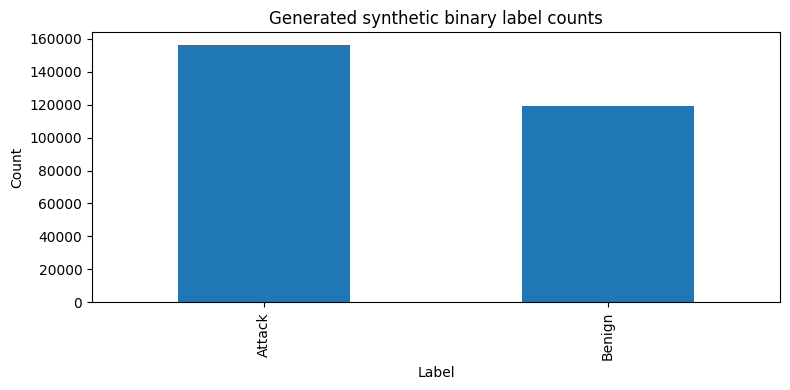

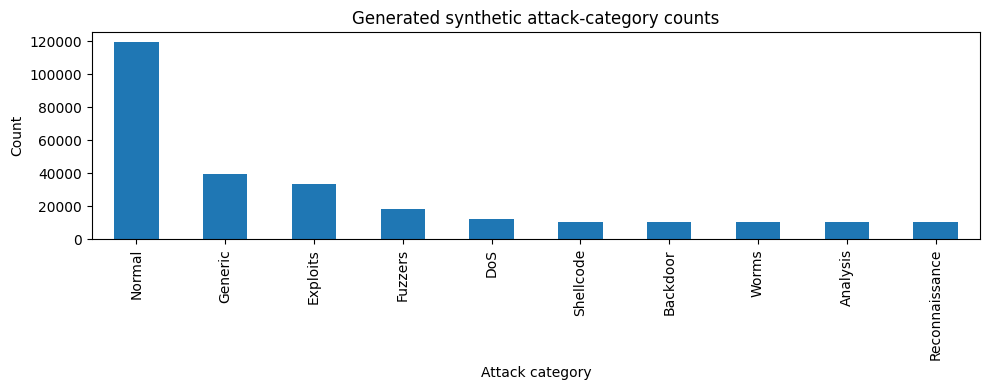

,task,model,accuracy,f1,macro_f1,auc,ovr_auc
2,binary,efficientnetb0_heatmap,0.715243,0.734157,NaN,0.804686,NaN
0,binary,heatwavenet_novel,0.699139,0.746543,NaN,0.792001,NaN
1,binary,resnet50_heatmap,0.620947,0.705228,NaN,0.649031,NaN
5,multiclass,efficientnetb0_heatmap,0.237827,NaN,0.207664,NaN,0.739819
3,multiclass,heatwavenet_novel,0.248284,NaN,0.189723,NaN,0.748161
4,multiclass,resnet50_heatmap,0.052649,NaN,0.055954,NaN,0.604524


In [14]:
plt.figure(figsize=(8, 4))
syn["label"].map({0: "Benign", 1: "Attack"}).value_counts().plot(kind="bar")
plt.title("Generated synthetic binary label counts")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
syn["attack_cat"].value_counts().head(10).plot(kind="bar")
plt.title("Generated synthetic attack-category counts")
plt.xlabel("Attack category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

if len(results_df):
    cols = [c for c in ["accuracy", "f1", "macro_f1", "auc", "ovr_auc"] if c in results_df.columns]
    display(results_df[["task", "model"] + cols])


## Package Notebook Outputs

All generated reports, plots, datasets, and evaluation files are compressed into a final output zip for reuse in the thesis workflow.


In [15]:
final_zip = OUTPUT_ROOT / "balanced_ipv6_generation_and_eval_outputs.zip"
with zipfile.ZipFile(final_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_ROOT.rglob("*"):
        if p.is_file() and p.name != final_zip.name:
            zf.write(p, arcname=str(p.relative_to(OUTPUT_ROOT)))
print("Final outputs zip:", final_zip.resolve())


Final outputs zip: /kaggle/working/balanced_ipv6_generation_and_eval/balanced_ipv6_generation_and_eval_outputs.zip
